# Monte Carlo Control in a Windy GridWorld

## Problem

An agent must learn to navigate in a 5x5 grid from bottom-left corner (0, 0) to the top-right corner (4, 4). At each step, it chooses one of four actions [up, down, left, right], moving one cell in the chosen direction.

## Environment

- **Wind**: at each agent's movement, wind may push the agent in some direction with different magnitudes, depending on the specific implementation.
- **Walls**: the agent cannot exit the grid; when it hits a wall (i.e. its position results outside the grid), it is clipped back into the grid and suffers a penalty.
- **Rewards**: +1 for reaching the goal, -0.1 for hitting a wall, 0 otherwise.
- **Episodes**: an episode ends when the agent reaches the goal, or after 200 steps. The discount factor is $\gamma = 0.9$.

## Analysis

Most of the logic is encapsulated in the classes inside <code>windy_gridworld</code>. This notebook only contains the analysis.

In [1]:
import sys
sys.path.append('..')

from windy_gridworld import Agent, MCAgent, QLearningAgent, ExpectedSarsaAgent
from windy_gridworld import StochasticWindGridEnvironment

FIGURES_FOLDER = '../figures/'

def test_agent(agent: Agent, name_agent: str) -> list[float]:
    agent.evaluate().draw(save_to = 
                          FIGURES_FOLDER + name_agent + '_evaluate_before_training.png')
    returns = agent.train()
    agent.evaluate().draw(save_to = 
                          FIGURES_FOLDER + name_agent + '_evaluate_after_training.png')
    return returns

### Approach 1: Monte Carlo

We use tabular Monte Carlo methods (both prediction and control, where exploration is ensured through $\epsilon$-soft policies), which learn from complete episodes. The algorithms used are in the following images:

![MC prediction](https://i.imgur.com/jQW04aG.png)

![MC control](https://i.imgur.com/0sz7irr.png)

*Algorithm boxes: R. S. Sutton and A. G. Barto, Reinforcement Learning: An Introduction, 2nd ed. (2018), Sections 5.1 and 5.4.*

100%|██████████| 5000/5000 [00:38<00:00, 129.42it/s]


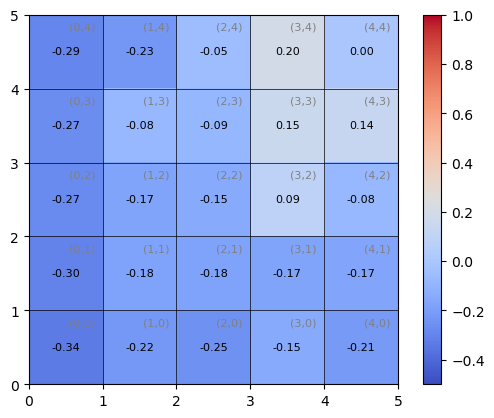

100%|██████████| 5000/5000 [00:05<00:00, 872.25it/s]


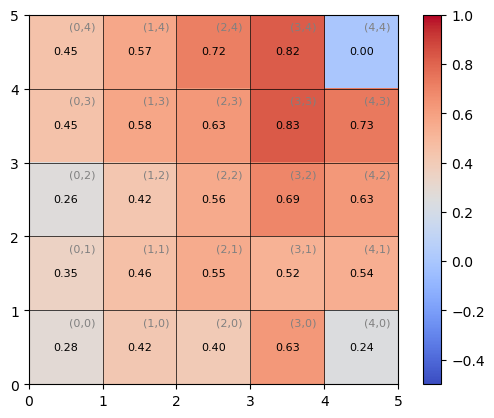

In [2]:
mc_returns = test_agent(MCAgent(StochasticWindGridEnvironment()), 'MC')

### Approach 2: TD(0) with Q-learning

We use tabular TD(0) methods (both prediction and control with Q-learning, where exploration is ensured throug $\epsilon$-soft policies), which learn step-by-step. The algorithms used are in the following images:


![TD(0) prediction](https://i.imgur.com/SD9xaEx.png)

![TD(0) control Q-learning](https://i.imgur.com/WNAE8rH.png)

*Algorithm boxes: R. S. Sutton and A. G. Barto, Reinforcement Learning: An Introduction, 2nd ed. (2018), Sections 6.1 and 6.5.*

100%|██████████| 5000/5000 [00:43<00:00, 115.26it/s]


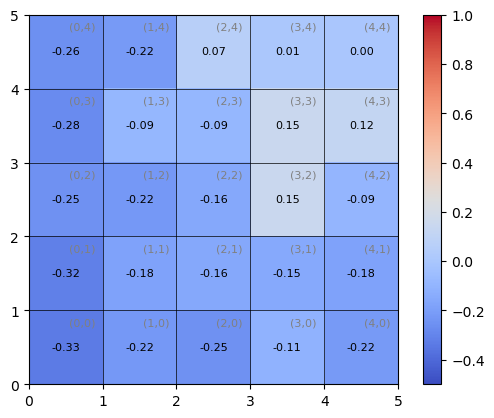

100%|██████████| 5000/5000 [00:06<00:00, 727.02it/s]


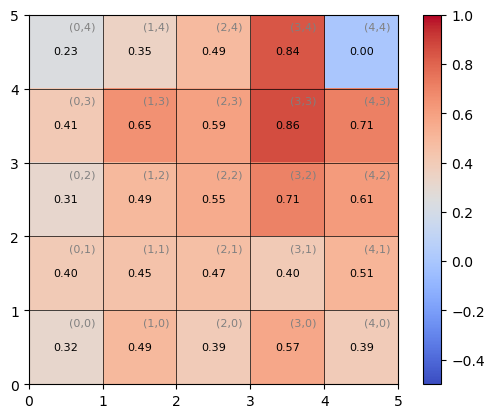

In [3]:
qlearning_returns = test_agent(QLearningAgent(StochasticWindGridEnvironment()), 'QLearning')

### Approach Extra: TD(0) with Expected SARSA

100%|██████████| 5000/5000 [00:42<00:00, 116.28it/s]


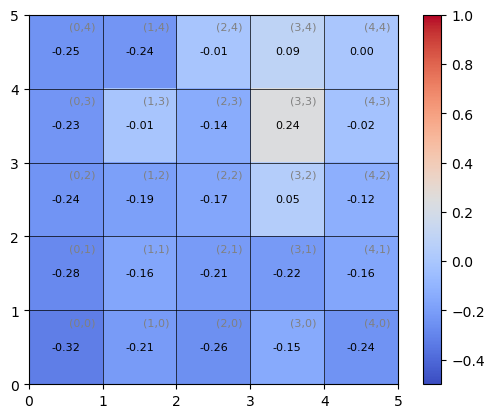

100%|██████████| 5000/5000 [00:05<00:00, 849.64it/s]


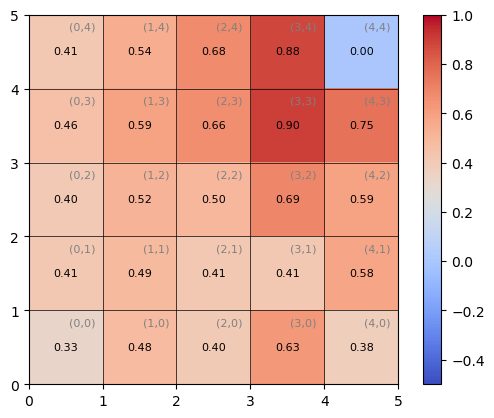

In [4]:
expSARSA_returns = test_agent(ExpectedSarsaAgent(StochasticWindGridEnvironment()),
                              'ExpectedSARSA')

### Comparing the Returns

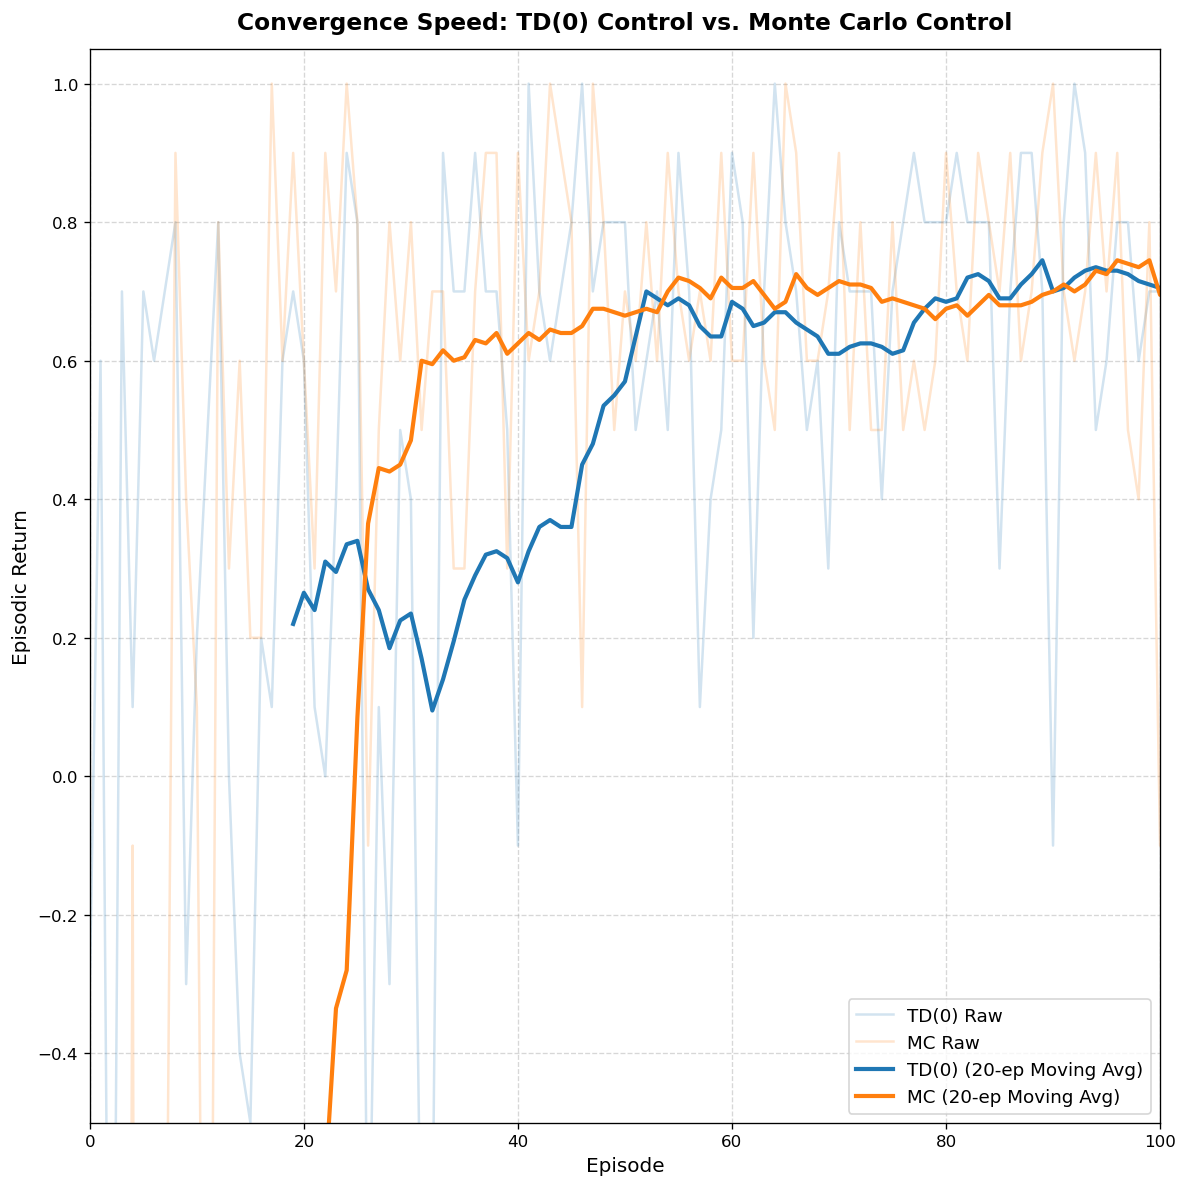

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# a script to compare the returns of MC and TD(0) Q-learning: this is useful for 
# understanding the difference in the convergence speed.
WINDOW_SIZE = 20
def moving_average(data, window = WINDOW_SIZE):
    weights = np.ones(window) / window
    return np.convolve(data, weights, mode='valid')

td_smooth = moving_average(qlearning_returns)
mc_smooth = moving_average(mc_returns)
x_smoothed = np.arange(WINDOW_SIZE - 1, len(qlearning_returns))
plt.figure(figsize = (10, 10), dpi = 120)
plt.plot(qlearning_returns, color = '#1f77b4', alpha=0.2, label='TD(0) Raw')
plt.plot(mc_returns, color = '#ff7f0e', alpha=0.2, label='MC Raw')
plt.plot(x_smoothed, td_smooth, color = '#1f77b4', linewidth=2.5, label=f'TD(0) ({WINDOW_SIZE}-ep Moving Avg)')
plt.plot(x_smoothed, mc_smooth, color = '#ff7f0e', linewidth=2.5, label=f'MC ({WINDOW_SIZE}-ep Moving Avg)')
plt.xlim(0, 100)        # zoom in on the early episodes
plt.ylim(-0.5, 1.05)    # droput extreme outliers  
plt.title('Convergence Speed: TD(0) Control vs. Monte Carlo Control', fontsize = 14, fontweight = 'bold', pad = 12)
plt.xlabel('Episode', fontsize = 12)
plt.ylabel('Episodic Return', fontsize = 12)
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.legend(loc = 'lower right', fontsize = 11)
plt.tight_layout()
plt.savefig(FIGURES_FOLDER + 'convergence_comparison.png', dpi = 300)
plt.show()

TD(0) gets to decent results quickly.

In [6]:
results = {
    'Monte Carlo'       : mc_returns,
    'Q-learning'        : qlearning_returns,
    'Expected SARSA'    : expSARSA_returns
}
print(f"{'Agent Strategy':<20} | {'Mean Return':>12} | {'Std Dev':>10}")
print("-" * 48)
for name, returns in results.items():
    print(f'{name:<20} | {np.mean(returns):>12.2f} | {np.std(returns):>10.2f}')

Agent Strategy       |  Mean Return |    Std Dev
------------------------------------------------
Monte Carlo          |         0.76 |       0.28
Q-learning           |         0.81 |       0.14
Expected SARSA       |         0.79 |       0.15
